# Stage 9b — Connectivity x land-use: the 2x2 comparison

**Pairs with Stage 9** (sensitivity). With both connectivity and land-use
pressure now restructured into explicit v1/v2 versions (see `README.md`),
this notebook computes relative risk under all four combinations and
reports which axis moves the final map more.

Connectivity v2 = slope + watercourse (+ D8 routing at Mole Creek only,
from `connectivity-hydlines`). Land-use v2 = LIST matrix
(`notebooks/05b_landuse_pressure_list.ipynb`).


In [1]:
from pathlib import Path
import os, sys
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.io import MemoryFile
from rasterio.mask import mask
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
from karst import (add_karst_susceptibility, add_connectivity, add_connectivity_v2, rasterize_max,
                   in_mole_creek_focus, mole_creek_focus_mask, aggregate_pressure_by_system)
from hydro import score_watercourses, watercourse_raster, mean_slope_by_polygon, add_d8_connectivity, slope_degrees, slope_risk_multiplier
from landuse_list import MATRIX, load_list_landuse, pressure_raster
from mapping import add_attribution, finish_map

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
inpath = data / "Input_data"
outpath = data / "Output_data"

def corr_nonzero(a, b, valid_mask):
    m = valid_mask & ~np.isnan(a) & ~np.isnan(b) & ((a > 0) | (b > 0))
    return np.corrcoef(a[m], b[m])[0, 1]

def named_ranking(risk, karst_only, shape, transform, valid_mask):
    profile = {"driver": "GTiff", "height": shape[0], "width": shape[1], "count": 1,
               "dtype": "float32", "crs": "EPSG:7855", "transform": transform, "nodata": -9999}
    rows = []
    with MemoryFile() as mem:
        with mem.open(**profile) as dst:
            dst.write(np.where(valid_mask & ~np.isnan(risk), risk, -9999).astype("float32"), 1)
        with mem.open() as src:
            for name, group in karst_only.dropna(subset=["KNAME"]).groupby("KNAME"):
                img, _ = mask(src, list(group.geometry), crop=True, nodata=-9999)
                v = img[0]; v = v[v != -9999]
                rows.append({"KNAME": name, "mean_risk": v.mean() if len(v) else np.nan, "n_px": len(v)})
    return pd.DataFrame(rows).sort_values("mean_risk", ascending=False).reset_index(drop=True)


## 1. Mole Creek (25 m)


In [2]:
with rasterio.open(outpath / "karst_intensity_mc_EPSG7855.tif") as src:
    intensity = src.read(1).astype(float)
with rasterio.open(outpath / "connectivity_atlas_mc_EPSG7855.tif") as src:
    conn_v1 = src.read(1).astype(float)
with rasterio.open(outpath / "dem_mc_EPSG7855.tif") as src:
    dem = src.read(1); dem_nodata = src.nodata; transform = src.transform; shape = dem.shape
    cell = abs(src.transform.a); bounds = src.bounds
with rasterio.open(outpath / "landuse_pressure_mc_2020_EPSG7855.tif") as src:
    dea = src.read(1).astype(float); dea_nodata = src.nodata

karst_mc = gpd.read_file(outpath / "karst_mc_connectivity_EPSG7855.gpkg")
karst_mc = karst_mc[karst_mc.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
focus = mole_creek_focus_mask(karst_mc, shape, transform)
valid = (dem != dem_nodata) & focus
karst_only = karst_mc[(karst_mc["karst_intensity"] > 0) & in_mole_creek_focus(karst_mc)]

S = intensity / 4.0
slope = slope_degrees(dem, dem_nodata, cell)
add_connectivity_v2(karst_mc, mean_slope_by_polygon(karst_mc, slope, transform))
conn_slope_poly = rasterize_max(karst_mc, "connectivity_v2", shape, transform, fill=0, dtype="float32").astype(float)

wc = gpd.read_file(outpath / "watercourses_tas_EPSG7855.gpkg")
wc = score_watercourses(wc[wc["HYDLNTY1"] == "Watercourse"] if "HYDLNTY1" in wc.columns else wc)
mc_bounds = gpd.read_file(outpath / "mole_creek_bounding_box_EPSG7855.gpkg").total_bounds
wc_mc = wc.cx[mc_bounds[0]:mc_bounds[2], mc_bounds[1]:mc_bounds[3]]
wc_cell = watercourse_raster(wc_mc, shape, transform).astype(float)
conn_sw = np.where(intensity > 0, np.maximum(conn_slope_poly, wc_cell), conn_v1)

karst_mc_d8 = add_d8_connectivity(karst_mc.copy(), outpath / "karst_upstream_connectivity_counts_core_mc_25m_EPSG7855_alt3_jenks5.csv")
d8_poly = rasterize_max(karst_mc_d8.dropna(subset=["d8_score"]), "d8_score", shape, transform, fill=0, dtype="float32").astype(float)
C2 = np.where(intensity > 0, np.maximum(conn_sw, d8_poly), conn_v1) / 3.0
C1 = conn_v1 / 3.0
intrinsic_v1, intrinsic_v2 = S * C1, S * C2

lu = load_list_landuse(inpath / "LIST_LAND_USE_2021_STATEWIDE" / "list_land_use_2021_statewide.shp",
                        "EPSG:7855", bounds_target=tuple(bounds))
p_list = pressure_raster(lu, MATRIX, shape, transform).astype(float)
top = max(MATRIX.values())
eff_list = aggregate_pressure_by_system(karst_mc, p_list, transform, -1)
eff_dea = aggregate_pressure_by_system(karst_mc, dea, transform, dea_nodata)

# Top-level slope factor is part of the frozen v1 formula (R = S x C x P x slope, Stage 6/7).
# Applied uniformly to all four combos here, including v2, even though v2's connectivity
# already folds in its own per-polygon mean-slope scoring (add_connectivity_v2 above) --
# so the "v2" rows below double-count slope on purpose, to hold slope treatment fixed
# while isolating the connectivity-axis and land-use-axis comparisons from each other.
# The production v2 candidate (Stage 13) does NOT stack the two; see that notebook for
# the actual non-double-counted v2 formula.
slope_factor = slope_risk_multiplier(slope)

combos = {
    "v1 conn x DEA (frozen)": np.where(valid, intrinsic_v1 * eff_dea / 3.0 * slope_factor, np.nan),
    "v1 conn x LIST":         np.where(valid & (eff_list >= 0), intrinsic_v1 * eff_list / top * slope_factor, np.nan),
    "v2 conn x DEA":          np.where(valid, intrinsic_v2 * eff_dea / 3.0 * slope_factor, np.nan),
    "v2 conn x LIST":         np.where(valid & (eff_list >= 0), intrinsic_v2 * eff_list / top * slope_factor, np.nan),
}
baseline = combos["v1 conn x DEA (frozen)"]

rows = [{"combination": name, "mean risk": round(np.nanmean(r[valid]), 4),
         "r vs frozen": round(corr_nonzero(baseline, r, valid), 4)} for name, r in combos.items()]
print(pd.DataFrame(rows).to_string(index=False))

table = named_ranking(baseline, karst_only, shape, transform, valid).set_index("KNAME")[["mean_risk"]].rename(columns={"mean_risk": "v1 x DEA"})
for name in list(combos)[1:]:
    table[name] = named_ranking(combos[name], karst_only, shape, transform, valid).set_index("KNAME")["mean_risk"]
print("\nMean risk by Mole Creek area:")
print(table.round(3).to_string())


           combination  mean risk  r vs frozen
v1 conn x DEA (frozen)     0.1950       1.0000
        v1 conn x LIST     0.1260       0.9965
         v2 conn x DEA     0.1917       0.9684
        v2 conn x LIST     0.1239       0.9636

Mean risk by Mole Creek area:
                              v1 x DEA  v1 conn x LIST  v2 conn x DEA  v2 conn x LIST
KNAME                                                                                
Mole Creek  (Chudleigh Hill)     0.268           0.221          0.268           0.221
Mole Creek                       0.202           0.129          0.198           0.127
Meander - Western Creek          0.089           0.076          0.089           0.076


### Figure


cell_3:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


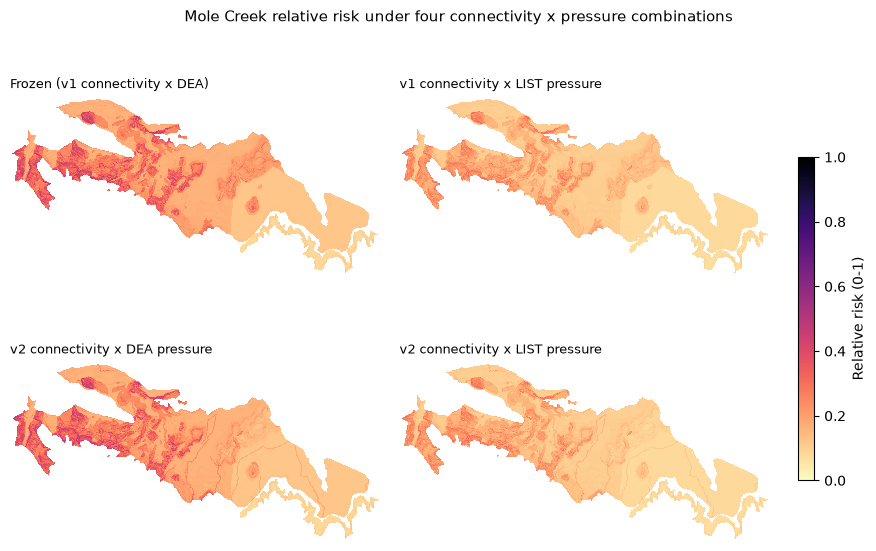

In [3]:
import matplotlib as mpl
cmap = mpl.colormaps["magma_r"].copy(); cmap.set_bad("white")
rows_px, cols_px = np.nonzero(valid)
r0, r1 = max(rows_px.min()-10, 0), min(rows_px.max()+10, valid.shape[0])
c0, c1 = max(cols_px.min()-10, 0), min(cols_px.max()+10, valid.shape[1])
panel_h = 2.6; panel_w = panel_h * ((c1 - c0) / (r1 - r0))

fig, axes = plt.subplots(2, 2, figsize=(panel_w * 2 + 1.2, panel_h * 2 + 0.8), sharex=True, sharey=True,
                          gridspec_kw={"hspace": 0.35, "wspace": 0.05})
labels = {"v1 conn x DEA (frozen)": "Frozen (v1 connectivity x DEA)",
          "v1 conn x LIST": "v1 connectivity x LIST pressure",
          "v2 conn x DEA": "v2 connectivity x DEA pressure",
          "v2 conn x LIST": "v2 connectivity x LIST pressure"}
for ax, (key, title) in zip(axes.ravel(), labels.items()):
    arr = combos[key][r0:r1, c0:c1]
    v = valid[r0:r1, c0:c1]
    masked = np.ma.masked_where(~v | np.isnan(arr), arr)
    im = ax.imshow(masked, cmap=cmap, vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title, fontsize=9, loc="left")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
fig.colorbar(im, ax=axes, shrink=0.7, pad=0.03, label="Relative risk (0-1)")
fig.suptitle("Mole Creek relative risk under four connectivity x pressure combinations", fontsize=11, y=1.01)
fig.savefig(Path("..") / "figures" / "connectivity_landuse_2x2_mole_creek.png", dpi=200, bbox_inches="tight")
plt.show()


## 2. Statewide (100 m)

Connectivity v2 here is slope + watercourse only (the D8 signal does not cover statewide karst).


In [4]:
tasmania = gpd.read_file(outpath / "tasmania_bounding_box_EPSG7855.gpkg")
with rasterio.open(outpath / "dem_tas_100m_EPSG7855.tif") as src:
    tdem = src.read(1); tnodata = src.nodata; ttransform = src.transform; tshape = tdem.shape; tcell = abs(src.transform.a)
    land, _ = mask(src, tasmania.geometry, crop=False, nodata=tnodata)
tvalid = land[0] != tnodata

karst_tas = gpd.read_file(inpath / "KarstAtlas/Karst_Ver_3_1/Karst_Atlas_v3_1.shp").to_crs("EPSG:7855")
karst_tas = karst_tas[karst_tas.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
add_karst_susceptibility(karst_tas); add_connectivity(karst_tas)
t_int = rasterize_max(karst_tas, "karst_intensity", tshape, ttransform).astype(float)
t_conn1 = rasterize_max(karst_tas, "connectivity", tshape, ttransform).astype(float)
tkarst = (t_int > 0) & tvalid
tkarst_only = karst_tas[karst_tas["karst_intensity"] > 0]

tS = t_int / 4.0
tslope = slope_degrees(tdem, tnodata, tcell)
add_connectivity_v2(karst_tas, mean_slope_by_polygon(karst_tas, tslope, ttransform))
t_conn_slope = rasterize_max(karst_tas, "connectivity_v2", tshape, ttransform, fill=0, dtype="float32").astype(float)
t_wc = watercourse_raster(wc, tshape, ttransform).astype(float)
tC2 = np.where(t_int > 0, np.maximum(t_conn_slope, t_wc), t_conn1) / 3.0
tC1 = t_conn1 / 3.0
t_intrinsic_v1, t_intrinsic_v2 = tS * tC1, tS * tC2

with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src:
    tbase_file = src.read(1).astype(float); trn = src.nodata
tbase_file = np.where(tvalid & (tbase_file != trn), tbase_file, np.nan)

# The saved raster is now S x C1 x P x slope (Stage 7, frozen). Back-solve pure
# effective pressure by dividing out S x C1 x slope, so the top-level slope factor
# can then be applied uniformly below (including on the v2 combos -- deliberately
# double-counting slope there, same reasoning as the Mole Creek cell above, to hold
# slope treatment fixed while isolating the connectivity-axis and land-use-axis
# comparisons from each other; the production v2 candidate, Stage 13, does not
# stack the two).
tslope_factor = slope_risk_multiplier(tslope)
t_denominator = t_intrinsic_v1 * tslope_factor
t_eff_dea_norm = np.where(t_denominator > 0, tbase_file / np.where(t_denominator > 0, t_denominator, 1), 0.0)

lu_t = load_list_landuse(inpath / "LIST_LAND_USE_2021_STATEWIDE" / "list_land_use_2021_statewide.shp", "EPSG:7855")
t_p_list = pressure_raster(lu_t, MATRIX, tshape, ttransform).astype(float)
t_eff_list = aggregate_pressure_by_system(karst_tas, t_p_list, ttransform, -1)

tcombos = {
    "v1 conn x DEA (frozen)": tbase_file,
    "v1 conn x LIST":         np.where(tvalid & (t_eff_list >= 0), t_intrinsic_v1 * t_eff_list / top * tslope_factor, np.nan),
    "v2 conn x DEA":          np.where(tvalid, t_intrinsic_v2 * t_eff_dea_norm * tslope_factor, np.nan),
    "v2 conn x LIST":         np.where(tvalid & (t_eff_list >= 0), t_intrinsic_v2 * t_eff_list / top * tslope_factor, np.nan),
}
tbaseline = tcombos["v1 conn x DEA (frozen)"]

rows = [{"combination": name, "mean risk (karst)": round(np.nanmean(r[tkarst]), 4),
         "r vs frozen": round(corr_nonzero(tbaseline, r, tvalid), 4)} for name, r in tcombos.items()]
print(pd.DataFrame(rows).to_string(index=False))

ttable = named_ranking(tbaseline, tkarst_only, tshape, ttransform, tvalid).set_index("KNAME")[["mean_risk"]].rename(columns={"mean_risk": "v1 x DEA"})
for name in list(tcombos)[1:]:
    ttable[name] = named_ranking(tcombos[name], tkarst_only, tshape, ttransform, tvalid).set_index("KNAME")["mean_risk"]
print("\nTop 10 named areas:")
print(ttable.sort_values("v1 x DEA", ascending=False).head(10).round(3).to_string())


           combination  mean risk (karst)  r vs frozen
v1 conn x DEA (frozen)             0.1417       1.0000
        v1 conn x LIST             0.0737       0.8190
         v2 conn x DEA             0.1423       0.9911
        v2 conn x LIST             0.0740       0.8113

Top 10 named areas:
                                v1 x DEA  v1 conn x LIST  v2 conn x DEA  v2 conn x LIST
KNAME                                                                                  
Welcome River (1) / Port Hills     0.401           0.241          0.268           0.161
Doctors Rocks                      0.396           0.328          0.396           0.328
Vinegar Hill                       0.378           0.227          0.378           0.227
Flowery Gully                      0.369           0.336          0.369           0.336
Grim-Trefoil                       0.364           0.212          0.364           0.212
Emita - Memana (2)                 0.355           0.210          0.355           0.210


## Result

(All four combinations here carry the same top-level slope factor from the frozen
formula, including the v2 rows, so the comparison below is a clean test of connectivity
choice and land-use choice in isolation. The actual v2 candidate evaluated in Stage 13
does not stack the top-level factor on top of v2's own internal slope scoring, to avoid
double-counting it there.)

**Which axis matters more now depends on scale.** Switching land-use alone (v1 to v2
pressure, same connectivity) drops correlation with the frozen baseline to r=0.997
(Mole Creek) / r=0.819 (statewide); switching connectivity alone (same DEA pressure)
drops it to r=0.968 (Mole Creek) / r=0.991 (statewide). At Mole Creek the two axes are
close but connectivity now has the larger effect; statewide, land-use still has the much
larger effect, as before. The two changes compound rather than cancel: the worst-case
combination (v2 connectivity x LIST pressure) correlates at r=0.964 (Mole Creek) / r=0.811
(statewide) with the frozen method, slightly below either axis alone.

Land-use remains the higher-leverage choice statewide, where the data this project
actually has to choose between (DEA vs. LIST) matters most. Land-use v2 (LIST) also
roughly halves mean risk everywhere (natural land scores 1/10 instead of 1/3) -- a level
shift, not a ranking one, but it means the fixed 0.2-wide risk classes would need
recalibrating if LIST becomes the default.
